In [3]:
# Task 1 : Data Loading and Inspection

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Loading the dataset

df = pd.read_csv('C:\\Users\\Lenovo\\OneDrive\\Desktop\\ml-assignment-satvinder-singh\\data\\q1_heart_disease.csv')

# Display data shapes, data types and missing value counts

print("Shape :", df.shape)
print("\nData Types :\n", df.dtypes)
print("\nMissing Values :\n", df.isnull().sum())
df.head()

Shape : (800, 12)

Data Types :
 age                  int64
sex                  int64
chest_pain_type        str
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg            str
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope               str
heart_disease        int64
dtype: object

Missing Values :
 age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


The dataset contains 800 patient records and 12 factors, including both numerical and categorical variables with some missing values in resting_bp and cholesterol.

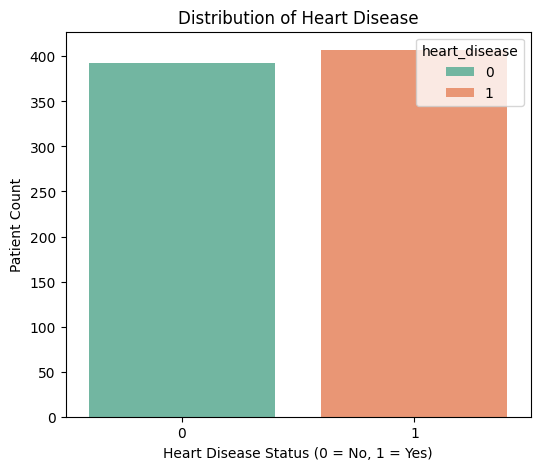

In [4]:
# Task 2 : Exploratory Data Analysis (EDA)

# Plot 1 : Target Class Distribution
plt.figure(figsize=(6,5))
sns.countplot(data=df, x='heart_disease', hue='heart_disease', palette='Set2')
plt.title('Distribution of Heart Disease')
plt.xlabel('Heart Disease Status (0 = No, 1 = Yes)')
plt.ylabel('Patient Count')
plt.show()

The dataset shows a nearly equal no. of patients with and without heart disease, indicating a balanced distribution.

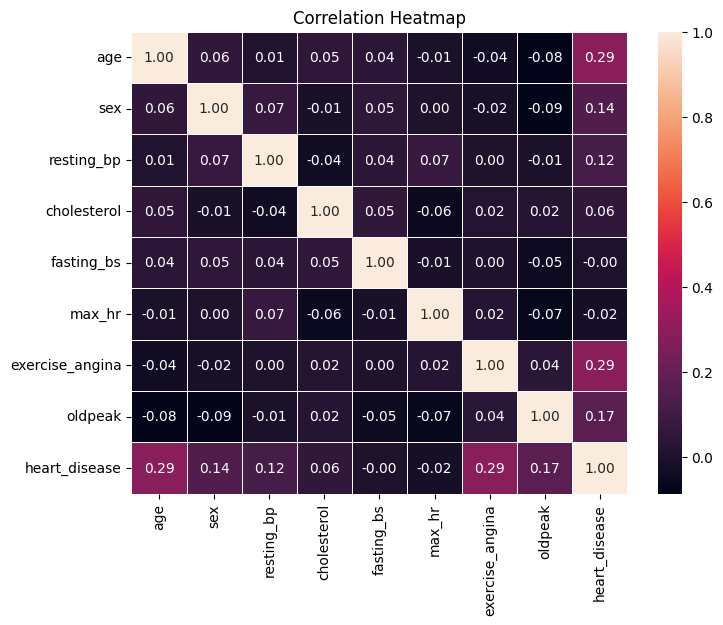

In [5]:
# Plot 2 : Correlation Heatmap
plt.figure(figsize=(8,6))

# Create a correlation matrix
corr = df.select_dtypes(include=[np.number]).corr()

# Plot the heatmap
sns.heatmap(corr, annot=True, fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

Most factors have weak correlations, though age and exercise angina show a relatively stronger relationship with heart disease. 

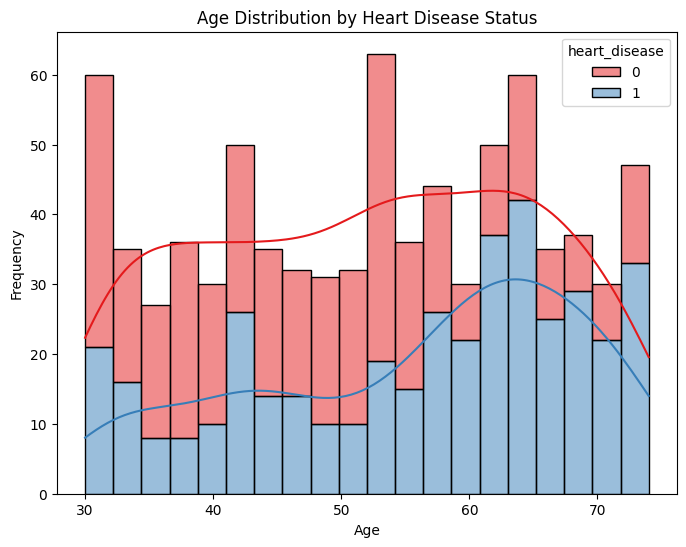

In [6]:
# Plot 3 : Age Distribution by Heart Disease Status
plt.figure(figsize=(8,6))
sns.histplot(data=df, x='age', hue='heart_disease',kde=True, multiple='stack', palette='Set1', bins=20)
plt.title('Age Distribution by Heart Disease Status')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

Heart disease cases are more frequent in higher age grpoups, suggesting age is an important factor.

In [7]:
# Task 3 : Data Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# 1 : Define features and target
x = df.drop('heart_disease', axis=1)
y = df['heart_disease']

# 2 : Identify column types
num_cols = x.select_dtypes(include=['int64', 'float64']).columns
cat_cols = x.select_dtypes(include=['object', 'category', 'string']).columns

# 3 : Create pipelines for numeric and categorical features
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

# 4 : Combine pipelines into a ColumnTransformer
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

# 5 : Train test split with stratification
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, stratify=y, random_state=42
)

# 6 : Apply preprocessing to training and testing data
x_train_processed = preprocessor.fit_transform(x_train)
x_test_processed = preprocessor.transform(x_test)

print("Preprocessing complete :")
print("Training Shape :", x_train_processed.shape)
print("Testing Shape :", x_test_processed.shape)

Preprocessing complete :
Training Shape : (640, 15)
Testing Shape : (160, 15)


Missing values were handled using median and mode imputation, followed by encoding, scaling and stratified spliting.

In [8]:
# Task 4 : Model Training
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Initialize models
dt_model = DecisionTreeClassifier(random_state=42)
rf_model = RandomForestClassifier(random_state=42)
gb_model = GradientBoostingClassifier(random_state=42)

# Train models
dt_model.fit(x_train_processed, y_train)
rf_model.fit(x_train_processed, y_train)
gb_model.fit(x_train_processed, y_train)

print("All models trained successfully.")

All models trained successfully.


Three models -: Decision Tree, Random Forest and Gradient Boosting were trained successfully on the processed training data.

In [9]:
# Task 5 : Model Evaluation
from sklearn.metrics import confusion_matrix, classification_report

models = {
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model
}

for name, model in models.items():
    y_pred = model.predict(x_test_processed)
    print(f"Model Performance : {name}")
    print("Confusion Matrix :\n")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report :\n")
    print(classification_report(y_test, y_pred))
    print("-" * 50)

Model Performance : Decision Tree
Confusion Matrix :

[[57 22]
 [25 56]]

Classification Report :

              precision    recall  f1-score   support

           0       0.70      0.72      0.71        79
           1       0.72      0.69      0.70        81

    accuracy                           0.71       160
   macro avg       0.71      0.71      0.71       160
weighted avg       0.71      0.71      0.71       160

--------------------------------------------------
Model Performance : Random Forest
Confusion Matrix :

[[60 19]
 [15 66]]

Classification Report :

              precision    recall  f1-score   support

           0       0.80      0.76      0.78        79
           1       0.78      0.81      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160

--------------------------------------------------
Model Performance : Gradient Boosting
Confusio

The Random Forest model shows better performance compared to the other models. It achieves the highest F1-score and recall for class 1 (heart disease), making it more effective in identifying positive cases. Since recall is important in medical prediction, it is the most suitable model.

In [11]:
# Task 6 : Hyperparameter Tuning (Example with Random Forest)
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Define parameter grid for Random Forest
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

# Grid Search
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=10,
    scoring='f1',
    n_jobs=-1
)

# Fit on training data
grid_search.fit(x_train_processed, y_train)

# Best tuned model
best_rf = grid_search.best_estimator_

# Predictions with the best model
y_pred_tuned = best_rf.predict(x_test_processed)

print("\n----- Tuned Random Forest Performance -----")
print("Confusion Matrix :\n")
print(confusion_matrix(y_test, y_pred_tuned))

print("\nClassification Report :\n")
print(classification_report(y_test, y_pred_tuned))

# Compare with baseline model
baseline_pred = rf_model.predict(x_test_processed)

print("\n----- Baseline Accuracy -----")
print(accuracy_score(y_test, baseline_pred))
print("\n----- Tuned Model Accuracy -----")
print(accuracy_score(y_test, y_pred_tuned))


----- Tuned Random Forest Performance -----
Confusion Matrix :

[[57 22]
 [15 66]]

Classification Report :

              precision    recall  f1-score   support

           0       0.79      0.72      0.75        79
           1       0.75      0.81      0.78        81

    accuracy                           0.77       160
   macro avg       0.77      0.77      0.77       160
weighted avg       0.77      0.77      0.77       160


----- Baseline Accuracy -----
0.7875

----- Tuned Model Accuracy -----
0.76875


We used GridSearchCV with cross-validation to tune our Random Forest model. We chose the best parameters based on the F1-score. After testing, we saw that there was not much difference between the baseline and tuned model in accuracy. This means the original model was already working well.